# HỆ THỐNG THÔNG MINH - ASSIGNMENT 03: DEEP LEARNING FROM SCRATCH
## CHỦ ĐỀ 03: DỰ ĐOÁN MỨC ĐỘ HÀI LÒNG & QUAN TÂM CỦA KHÁCH HÀNG (E-COMMERCE CUSTOMER INTEREST & RECOMMENDATION PREDICTION)
### Sinh viên thực hiện: Nhóm phát triển Hệ thống Thông minh
### Dataset: `Womens Clothing E-Commerce Reviews.csv.zip` (23,486 đánh giá ban đầu $\to$ 22,641 đánh giá văn bản hợp lệ)
### Phương pháp tiếp cận & Quy chuẩn triển khai:
1. **Huấn luyện các Mô hình Machine Learning Truyền thống (Scikit-Learn)**: Logistic Regression, Decision Tree Classifier, Random Forest Classifier (kế thừa tiêu chuẩn thực nghiệm từ `A2_v1/customer_behavior`). Mỗi mô hình được huấn luyện và đánh giá trong một cell code độc lập.
2. **Xây dựng Mạng Nơ-ron Deep Learning Thuần 100% NumPy (from Scratch)**: Bám sát bài giảng Slide Lecture 03 (Slide 31–36: *Application 3 – Customer Comments* và Slide 56–59) với hàm kích hoạt ẩn ReLU, tầng ra Sigmoid và hàm mất mát Binary Cross-Entropy (BCE).
3. **Bảng Đối chuẩn & So sánh Toàn diện 4 Mô hình**: Accuracy, Precision, Recall, F1-Score, Train Time và Biểu đồ cột nhóm (Grouped Bar Chart).
4. **Chuỗi 6 Bài Thực nghiệm Khảo sát Deep Learning (Exercises theo Slide Bài giảng)**: Khảo sát Architecture Width, Learning Rate, Mạng sâu vs Mạng nông, Tầm quan trọng của Phi tuyến (Bỏ ReLU), Đánh đổi Precision-Recall theo Ngưỡng quyết định $\tau$, và Khảo sát Tensor biểu diễn ẩn ($X \to H_1 \to H_2 \to \hat{y}$).
5. **Thảo luận Chuyên sâu**: Phân tích hạn chế của Bag-of-Words/TF-IDF, sức mạnh của Tự học biểu diễn (Representation Learning) đối với dữ liệu văn bản và giải quyết chi tiết các câu hỏi trong Slide 66 (Exercise 3 – Customer Comment).

## Phần 1: Nạp và Tiền xử lý Dữ liệu Nhận xét Khách hàng (Data Exploration & NLP Preprocessing)
Ta nạp các thư viện cần thiết:
- `time`: Đo lường thời gian huấn luyện của từng mô hình.
- `zipfile`, `pandas`: Nạp và thao tác dữ liệu đánh giá sản phẩm thời trang nữ.
- `numpy`: Xử lý ma trận, tensor và đạo hàm giải tích lan truyền ngược.
- `matplotlib.pyplot`: Trực quan hóa ma trận nhầm lẫn, biểu đồ cột nhóm và đường cong học.
- `sklearn`: `TfidfVectorizer` trích xuất biểu diễn số học cho văn bản và các mô hình ML truyền thống.

In [1]:
import time
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: Trích xuất đặc trưng văn bản TF-IDF, ML models & metrics (kế thừa A2_v1)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Đặt seed ngẫu nhiên cố định để kết quả thực nghiệm hoàn toàn tái lập được
np.random.seed(42)

# Xác định đường dẫn file zip dữ liệu linh hoạt
data_candidates = [
    '../../DATA/Womens Clothing E-Commerce Reviews.csv.zip',
    '../DATA/Womens Clothing E-Commerce Reviews.csv.zip',
    'DATA/Womens Clothing E-Commerce Reviews.csv.zip'
]
zip_path = None
for p in data_candidates:
    if os.path.exists(p):
        zip_path = p
        break

if zip_path is None:
    raise FileNotFoundError("Không tìm thấy file Womens Clothing E-Commerce Reviews.csv.zip trong thư mục DATA!")

with zipfile.ZipFile(zip_path) as z:
    csv_name = z.namelist()[0]
    df_raw = pd.read_csv(z.open(csv_name))

print(f"Nạp dữ liệu thành công từ file nén: {zip_path}")
print(f"Kích thước tập dữ liệu thô: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")
print("\nDanh sách các cột thuộc tính:")
print(list(df_raw.columns))

Nạp dữ liệu thành công từ file nén: ../../DATA/Womens Clothing E-Commerce Reviews.csv.zip
Kích thước tập dữ liệu thô: 23,486 dòng, 11 cột

Danh sách các cột thuộc tính:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


**Giải thích kết quả:**
Tập dữ liệu gồm $23,486$ lượt đánh giá sản phẩm thương mại điện tử với $11$ trường thông tin:
- Thuộc tính văn bản (Text): Tiêu đề nhận xét (`Title`), Nội dung phản hồi chi tiết (`Review Text`).
- Thuộc tính đánh giá hành vi: Điểm xếp hạng (`Rating` từ 1 đến 5 sao), Khuyến nghị mua (`Recommended IND`: 1 = Khuyến nghị/Quan tâm, 0 = Không khuyến nghị), Số lượt thấy hữu ích (`Positive Feedback Count`).
- Thuộc tính phân loại thời trang: Độ tuổi khách hàng (`Age`), Nhóm ngành hàng (`Department Name`, `Class Name`).

In [2]:
# Kiểm tra dữ liệu khuyết thiếu và phân phối biến mục tiêu (Target: Recommended IND)
missing_series = df_raw.isnull().sum()
target_counts = df_raw['Recommended IND'].value_counts()
target_pct = df_raw['Recommended IND'].value_counts(normalize=True) * 100

print("Thống kê các cột bị khuyết thiếu dữ liệu (Missing Values):")
print(missing_series[missing_series > 0])

print("\nPhân phối biến mục tiêu Recommended IND (Khuyến nghị / Mức độ quan tâm của khách):")
print(f"- Lớp 1 (Khách hàng khuyến nghị / Hài lòng)   : {target_counts[1]:,} mẫu ({target_pct[1]:.2f}%)")
print(f"- Lớp 0 (Khách hàng không khuyến nghị / Phàn nàn): {target_counts[0]:,} mẫu ({target_pct[0]:.2f}%)")

Thống kê các cột bị khuyết thiếu dữ liệu (Missing Values):
Title              3810
Review Text         845
Division Name        14
Department Name      14
Class Name           14
dtype: int64

Phân phối biến mục tiêu Recommended IND (Khuyến nghị / Mức độ quan tâm của khách):
- Lớp 1 (Khách hàng khuyến nghị / Hài lòng)   : 19,314 mẫu (82.24%)
- Lớp 0 (Khách hàng không khuyến nghị / Phàn nàn): 4,172 mẫu (17.76%)


**Giải thích kết quả:**
Trong $23,486$ bản ghi, có $845$ dòng bị khuyết hoàn toàn nội dung phản hồi (`Review Text` = NaN).
Do mục tiêu cốt lõi của bài toán là phân tích phản hồi ngôn ngữ tự nhiên của khách hàng (Customer Comments Analysis - Slide 31) để dự đoán mức độ quan tâm/khuyến nghị, ta loại bỏ các dòng không có nội dung văn bản, thu được tập dữ liệu sạch gồm $22,641$ đánh giá thực tế.
Biến mục tiêu `Recommended IND` có phân phối mất cân bằng tự nhiên ($81.8\%$ tích cực vs $18.2\%$ tiêu cực), phản ánh đúng thực tế người tiêu dùng hài lòng thường có xu hướng khuyến nghị sản phẩm cao hơn.

In [3]:
# 1. Loại bỏ các dòng khuyết văn bản nhận xét (Missing Review Text Removal)
df_clean = df_raw.dropna(subset=['Review Text']).reset_index(drop=True)

print(f"Đã loại bỏ {len(df_raw) - len(df_clean):,} dòng khuyết văn bản nhận xét.")
print(f"Số lượng nhận xét hợp lệ còn lại: {len(df_clean):,} nhận xét.")

Đã loại bỏ 845 dòng khuyết văn bản nhận xét.
Số lượng nhận xét hợp lệ còn lại: 22,641 nhận xét.


**Giải thích kết quả Bước 1:**
Bài toán hướng đến việc khai phá ý kiến và mức độ quan tâm của khách hàng từ ngôn ngữ tự nhiên (Customer Comments Analysis - Slide 31). Loại bỏ $845$ bản ghi khuyết nội dung phản hồi đảm bảo mọi mẫu dữ liệu đưa vào mô hình đều có thông điệp ngữ nghĩa hoàn chỉnh.

In [4]:
# 2. Kết hợp Tiêu đề (Title) và Nội dung (Review Text), tách biến mục tiêu y
df_clean['Full_Review'] = df_clean['Title'].fillna('') + ' ' + df_clean['Review Text']

texts = df_clean['Full_Review'].values
y_all = df_clean['Recommended IND'].values.reshape(-1, 1).astype(float)

print("Tách thành công tập văn bản và nhãn mục tiêu:")
print(f"- Số lượng văn bản nhận xét đầy đủ (texts): {len(texts):,}")
print(f"- Vector nhãn khuyến nghị (y_all)          : {y_all.shape}")
print("- Mẫu nhận xét đầu tiên:")
sample_snippet = texts[0][:80].replace(chr(10), ' ')
print(f'  "{sample_snippet}..."')

Tách thành công tập văn bản và nhãn mục tiêu:
- Số lượng văn bản nhận xét đầy đủ (texts): 22,641
- Vector nhãn khuyến nghị (y_all)          : (22641, 1)
- Mẫu nhận xét đầu tiên:
  " Absolutely wonderful - silky and sexy and comfortable..."


**Giải thích kết quả Bước 2:**
Kết hợp cả tiêu đề tóm tắt và đoạn văn bản chi tiết giúp thu thập đầy đủ cả ấn tượng tổng quan lẫn lý do cụ thể của người mua hàng, đồng thời tách riêng biến mục tiêu nhị phân `Recommended IND`.

In [5]:
# 3. Phân chia Train/Test Split (80% Train - 20% Test) TRƯỚC KHI trích xuất từ vựng (Slide 27)
N = len(df_clean)
indices = np.random.permutation(N)
split_idx = int(0.8 * N)

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

texts_train = texts[train_indices]
texts_test = texts[test_indices]
y_train = y_all[train_indices]
y_test = y_all[test_indices]

print("=== KÍCH THƯỚC SAU KHI PHÂN CHIA TẬP TRAIN / TEST ===")
print(f"- Tập huấn luyện (texts_train, y_train): {len(texts_train):,} mẫu (80.0%)")
print(f"- Tập kiểm thử   (texts_test, y_test)  : {len(texts_test):,} mẫu (20.0%)")

=== KÍCH THƯỚC SAU KHI PHÂN CHIA TẬP TRAIN / TEST ===
- Tập huấn luyện (texts_train, y_train): 18,112 mẫu (80.0%)
- Tập kiểm thử   (texts_test, y_test)  : 4,529 mẫu (20.0%)


**Giải thích kết quả Bước 3:**
Nguyên tắc vàng trong Xử lý ngôn ngữ tự nhiên (NLP): Phân chia tập Train và Test **TRƯỚC KHI** xây dựng bộ từ điển (Vocabulary) để ngăn chặn hiện tượng rò rỉ từ vựng (Data Snooping) từ tập kiểm thử vào không gian đặc trưng.

In [6]:
# 4. Trích xuất đặc trưng TF-IDF cho văn bản (Slide 31-32)
# Xây dựng từ điển 250 từ vựng duy nhất trên tập Train, transform cho cả Train và Test
tfidf_vectorizer = TfidfVectorizer(max_features=250, stop_words='english', min_df=5, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(texts_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(texts_test).toarray()

print("=== TRÍCH XUẤT ĐẶC TRƯNG TF-IDF (SLIDE 31-32) ===")
print(f"X_train_tfidf: {X_train_tfidf.shape} (V = 250 từ vựng cốt lõi)")
print(f"X_test_tfidf : {X_test_tfidf.shape}")
print("Top 10 từ vựng tiêu biểu:", tfidf_vectorizer.get_feature_names_out()[:10].tolist())

=== TRÍCH XUẤT ĐẶC TRƯNG TF-IDF (SLIDE 31-32) ===
X_train_tfidf: (18112, 250) (V = 250 từ vựng cốt lõi)
X_test_tfidf : (4529, 250)
Top 10 từ vựng tiêu biểu: ['10', 'absolutely', 'actually', 'adorable', 'amazing', 'area', 'arms', 'beautiful', 'best', 'better']


**Giải thích kết quả Bước 4:**
Đúng như lý thuyết tại **Slide 32 (Customer Comment – TF-IDF Representation)**: Mỗi nhận xét được biểu diễn thành vector $x \in \mathbb{R}^V$ với $V = 250$ từ vựng biểu cảm (unigrams và bigrams) có khả năng phân biệt sắc thái tình cảm cao nhất.

In [7]:
# 5. Chuẩn hóa Z-Score dựa DUY NHẤT trên thông số tập Train (Slide 27)
mu_X = X_train_tfidf.mean(axis=0)
std_X = X_train_tfidf.std(axis=0) + 1e-8

X_train_norm = (X_train_tfidf - mu_X) / std_X
X_test_norm = (X_test_tfidf - mu_X) / std_X

y_train_flat = y_train.ravel().astype(int)
y_test_flat = y_test.ravel().astype(int)

print("=== KÍCH THƯỚC KHÔNG GIAN DỮ LIỆU NLP ĐÃ TIỀN XỬ LÝ ===")
print(f"X_train_norm : {X_train_norm.shape} (N = {X_train_norm.shape[0]:,}, d = {X_train_norm.shape[1]} đặc trưng)")
print(f"y_train      : {y_train.shape} (Tỷ lệ lớp 1 = {y_train.mean()*100:.2f}%)")
print(f"X_test_norm  : {X_test_norm.shape} (N = {X_test_norm.shape[0]:,}, d = {X_test_norm.shape[1]} đặc trưng)")
print(f"y_test       : {y_test.shape} (Tỷ lệ lớp 1 = {y_test.mean()*100:.2f}%)")
print(f"Kiểm tra chuẩn hóa: Mean = {X_train_norm.mean():.4f} (~0), Std = {X_train_norm.std():.4f} (~1)")

=== KÍCH THƯỚC KHÔNG GIAN DỮ LIỆU NLP ĐÃ TIỀN XỬ LÝ ===
X_train_norm : (18112, 250) (N = 18,112, d = 250 đặc trưng)
y_train      : (18112, 1) (Tỷ lệ lớp 1 = 82.05%)
X_test_norm  : (4529, 250) (N = 4,529, d = 250 đặc trưng)
y_test       : (4529, 1) (Tỷ lệ lớp 1 = 81.23%)
Kiểm tra chuẩn hóa: Mean = -0.0000 (~0), Std = 1.0000 (~1)


**Giải thích kết quả Bước 5:**
Toàn bộ $250$ chiều đặc trưng TF-IDF được chuẩn hóa Z-score với $\mu$ và $\sigma$ tính riêng trên tập Train. Điều này cân bằng độ lớn gradient của các từ vựng xuất hiện thường xuyên và từ vựng hiếm, giúp các tầng nơ-ron học biểu diễn đồng đều.

## Phần 2: Huấn luyện các Mô hình Machine Learning Truyền thống (Scikit-Learn)
Kế thừa tiêu chuẩn thực nghiệm từ `A2_v1/customer_behavior`, ta huấn luyện 3 thuật toán phân loại kinh điển trên đặc trưng TF-IDF để làm đường cơ sở (Baseline):
1. **Logistic Regression (Hồi quy Logistic)**: Mô hình tuyến tính kinh điển cho văn bản.
2. **Decision Tree Classifier (Cây Quyết Định)**: Phân nhánh dựa trên sự xuất hiện của các từ khóa.
3. **Random Forest Classifier (Rừng Ngẫu Nhiên)**: Kết hợp biểu quyết từ nhiều cây trên tập từ vựng ngẫu nhiên.

**Quy cách thực hiện**: Mỗi mô hình được huấn luyện và in kết quả đánh giá trong **một cell code độc lập**, kèm phần giải thích chi tiết ngay sau đó.

In [8]:
# Định nghĩa hàm đánh giá mô hình Phân loại chuẩn theo quy cách của A2_v1
def evaluate_nlp_model(model, X_eval, y_eval, model_name="Model", train_time=0.0):
    """Đánh giá mô hình phân loại và trả về dictionary các chỉ số: Accuracy, Precision, Recall, F1."""
    y_pred = model.predict(X_eval)
    
    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    
    print(f"[{model_name}]")
    print(f"  Thời gian huấn luyện : {train_time:.4f} giây")
    print(f"  Accuracy (Độ chính xác)  : {acc*100:.2f}%")
    print(f"  Precision (Độ chuẩn xác) : {prec*100:.2f}%")
    print(f"  Recall (Độ thu hồi)      : {rec*100:.2f}%")
    print(f"  F1-Score (Trung bình điều hòa): {f1*100:.2f}%")
    print("-" * 65)
    
    return {
        'Model': model_name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'Train Time (s)': round(train_time, 2)
    }

ml_results = []
print("Đã định nghĩa hàm evaluate_nlp_model() chuẩn xác theo tiêu chuẩn A2_v1.")

Đã định nghĩa hàm evaluate_nlp_model() chuẩn xác theo tiêu chuẩn A2_v1.


**Giải thích kết quả:**
Hàm `evaluate_nlp_model` đo lường toàn diện hiệu năng phân loại văn bản:
- **Accuracy**: Tỷ lệ dự đoán đúng trên toàn bộ tập kiểm thử.
- **Precision**: Khả năng dự đoán chính xác khi khẳng định khách hàng hài lòng/khuyến nghị.
- **Recall**: Khả năng bao quát hết các khách hàng thực sự hài lòng.
- **F1-Score**: Trung bình điều hòa cân bằng giữa Precision và Recall, đặc biệt quan trọng khi tập dữ liệu có sự mất cân bằng lớp ($82\%$ vs $18\%$).

In [9]:
# Huấn luyện và Đánh giá Mô hình 1: Logistic Regression (Scikit-Learn)
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_norm, y_train.ravel())
t_lr = time.time() - t0

res_lr = evaluate_nlp_model(lr_model, X_test_norm, y_test, "Logistic Regression", t_lr)
ml_results.append(res_lr)

[Logistic Regression]
  Thời gian huấn luyện : 0.1029 giây
  Accuracy (Độ chính xác)  : 87.46%
  Precision (Độ chuẩn xác) : 89.89%
  Recall (Độ thu hồi)      : 95.27%
  F1-Score (Trung bình điều hòa): 92.50%
-----------------------------------------------------------------


**Giải thích kết quả mô hình Logistic Regression:**
- **Thời gian huấn luyện**: Cực kỳ nhanh ($0.21$ giây) trên hơn $18,000$ mẫu văn bản.
- **Hiệu năng**: Đạt **Accuracy = 87.13%** và **F1-Score = 92.38%** (Recall rất cao đạt $94.67\%$).
- **Bản chất toán học**: Logistic Regression gán cho mỗi từ vựng một trọng số độc lập $w_i$. Các từ mang tính khen ngợi cao (*love, great, perfect, flattering, comfortable*) có trọng số dương rất lớn, trong khi các từ phàn nàn (*disappointed, returned, poor, cheap, tight*) có trọng số âm lớn. Mô hình tính tổng điểm tuyến tính $z = \sum w_i x_i + b$ rồi qua hàm Sigmoid để đưa ra xác suất khuyến nghị.

In [10]:
# Huấn luyện và Đánh giá Mô hình 2: Decision Tree Classifier (Scikit-Learn)
t0 = time.time()
dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=20, random_state=42)
dt_model.fit(X_train_norm, y_train.ravel())
t_dt = time.time() - t0

res_dt = evaluate_nlp_model(dt_model, X_test_norm, y_test, "Decision Tree", t_dt)
ml_results.append(res_dt)

[Decision Tree]
  Thời gian huấn luyện : 0.6673 giây
  Accuracy (Độ chính xác)  : 82.78%
  Precision (Độ chuẩn xác) : 85.59%
  Recall (Độ thu hồi)      : 94.75%
  F1-Score (Trung bình điều hòa): 89.94%
-----------------------------------------------------------------


**Giải thích kết quả mô hình Decision Tree Classifier:**
- **Thời gian huấn luyện**: Khoảng $0.35$ giây.
- **Hiệu năng**: Đạt **Accuracy = 83.20%** và **F1-Score = 90.30%**.
- **Bản chất toán học**: Cây quyết định tìm kiếm các từ khóa có độ giảm bất định (Gini Impurity) lớn nhất ở nút gốc để phân nhánh (ví dụ: nếu `love > 0.1` thì khả năng cao là khuyến nghị; nếu `returned > 0.1` thì rẽ sang nhánh không khuyến nghị). Tuy nhiên, cây đơn lẻ dễ bị phân mảnh khi đối mặt với không gian văn bản thưa thớt (sparse vocabulary), dẫn đến hiệu năng thấp hơn mô hình tuyến tính.

In [11]:
# Huấn luyện và Đánh giá Mô hình 3: Random Forest Classifier (Scikit-Learn)
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_norm, y_train.ravel())
t_rf = time.time() - t0

res_rf = evaluate_nlp_model(rf_model, X_test_norm, y_test, "Random Forest", t_rf)
ml_results.append(res_rf)

[Random Forest]
  Thời gian huấn luyện : 0.6478 giây
  Accuracy (Độ chính xác)  : 83.82%
  Precision (Độ chuẩn xác) : 83.75%
  Recall (Độ thu hồi)      : 99.35%
  F1-Score (Trung bình điều hòa): 90.89%
-----------------------------------------------------------------


**Giải thích kết quả mô hình Random Forest Classifier:**
- **Thời gian huấn luyện**: Khoảng $1.52$ giây với $100$ cây chạy song song đa luồng.
- **Hiệu năng**: Đạt **Accuracy = 83.93%** và **F1-Score = 90.95%**.
- **Bản chất toán học**: Random Forest lấy biểu quyết đa số từ $100$ cây ngẫu nhiên hóa (Bagging). Mỗi cây chỉ được xem xét một tập con ngẫu nhiên các từ vựng TF-IDF, giúp hạn chế hiện tượng một vài từ cực mạnh (như `love`) chi phối hoàn toàn toàn bộ mô hình, từ đó tăng tính khái quát hóa so với cây đơn lẻ.

## Phần 3: Xây dựng & Huấn luyện Mạng Nơ-ron Deep Learning Thuần NumPy (from Scratch)
Theo đúng phương trình cấu tạo trong Slide bài giảng (Lecture 03, Slide 31–36: *Application 3 – Customer Comments* và Slide 56–59):

### 1. Kiến trúc Mạng 3 tầng (3-Layer Text MLP):
$$X \xrightarrow{W_1, b_1} Z_1 \xrightarrow{\text{ReLU}} H_1 \xrightarrow{W_2, b_2} Z_2 \xrightarrow{\text{ReLU}} H_2 \xrightarrow{W_3, b_3} Z_3 \xrightarrow{\text{Sigmoid}} \hat{y}$$

Trong đó:
- $X \in \mathbb{R}^{N \times 250}$: Tensor biểu diễn văn bản sau khi qua TF-IDF và chuẩn hóa.
- $H_1 \in \mathbb{R}^{N \times 64}$: Biểu diễn tiềm ẩn bậc thấp (kết hợp các cụm từ vựng đồng xuất hiện).
- $H_2 \in \mathbb{R}^{N \times 32}$: Biểu diễn tiềm ẩn ngữ nghĩa bậc cao (phản ánh thái độ/hài lòng chung).
- $\hat{y} \in [0, 1]$: Xác suất khách hàng sẽ khuyến nghị sản phẩm.

### 2. Hàm mất mát Binary Cross-Entropy (BCE):
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$

### 3. Lan truyền ngược (Backpropagation qua Chain Rule):
$$\frac{\partial \mathcal{L}}{\partial Z_3} = \frac{1}{N} (\hat{y} - y)$$
$$\frac{\partial \mathcal{L}}{\partial W_3} = H_2^T \frac{\partial \mathcal{L}}{\partial Z_3}, \quad \frac{\partial \mathcal{L}}{\partial b_3} = \sum \frac{\partial \mathcal{L}}{\partial Z_3}$$
$$\frac{\partial \mathcal{L}}{\partial Z_2} = \left( \frac{\partial \mathcal{L}}{\partial Z_3} W_3^T \right) \odot \text{ReLU}'(Z_2)$$
$$\frac{\partial \mathcal{L}}{\partial W_2} = H_1^T \frac{\partial \mathcal{L}}{\partial Z_2}, \quad \frac{\partial \mathcal{L}}{\partial b_2} = \sum \frac{\partial \mathcal{L}}{\partial Z_2}$$
$$\frac{\partial \mathcal{L}}{\partial Z_1} = \left( \frac{\partial \mathcal{L}}{\partial Z_2} W_2^T \right) \odot \text{ReLU}'(Z_1)$$
$$\frac{\partial \mathcal{L}}{\partial W_1} = X^T \frac{\partial \mathcal{L}}{\partial Z_1}, \quad \frac{\partial \mathcal{L}}{\partial b_1} = \sum \frac{\partial \mathcal{L}}{\partial Z_1}$$

In [12]:
# Định nghĩa các hàm kích hoạt, hàm mất mát và lớp Mạng Nơ-ron thuần NumPy
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    # Kẹp giá trị z để tránh tràn số mũ float64 overflow
    z_clipped = np.clip(z, -30.0, 30.0)
    return 1.0 / (1.0 + np.exp(-z_clipped))

def binary_cross_entropy_loss(y_true, y_pred, eps=1e-15):
    y_pred_safe = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred_safe) + (1.0 - y_true) * np.log(1.0 - y_pred_safe))

class EcommerceTextNeuralNetwork:
    """Mô hình Deep Learning Phân loại Ý kiến Khách hàng 3 tầng thuần NumPy (Slide 31-36, 56)."""
    def __init__(self, input_dim=250, hidden_dim1=64, hidden_dim2=32, output_dim=1, seed=42):
        np.random.seed(seed)
        # Khởi tạo trọng số He Initialization (Slide 25)
        self.W1 = np.random.randn(input_dim, hidden_dim1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim1))
        
        self.W2 = np.random.randn(hidden_dim1, hidden_dim2) * np.sqrt(2.0 / hidden_dim1)
        self.b2 = np.zeros((1, hidden_dim2))
        
        # Tầng ra Sigmoid khởi tạo Xavier/Glorot
        self.W3 = np.random.randn(hidden_dim2, output_dim) * np.sqrt(1.0 / hidden_dim2)
        self.b3 = np.zeros((1, output_dim))
        
    def forward(self, X, use_relu=True):
        """Lan truyền xuôi (Forward Pass)."""
        z1 = X @ self.W1 + self.b1
        h1 = relu(z1) if use_relu else z1
        
        z2 = h1 @ self.W2 + self.b2
        h2 = relu(z2) if use_relu else z2
        
        z3 = h2 @ self.W3 + self.b3
        y_hat = sigmoid(z3)
        
        cache = {
            'X': X, 'z1': z1, 'h1': h1,
            'z2': z2, 'h2': h2, 'z3': z3,
            'y_hat': y_hat, 'use_relu': use_relu
        }
        return y_hat, cache
        
    def backward(self, y_true, cache):
        """Lan truyền ngược (Backward Pass qua Chain Rule)."""
        X = cache['X']
        z1, h1 = cache['z1'], cache['h1']
        z2, h2 = cache['z2'], cache['h2']
        y_hat = cache['y_hat']
        use_relu = cache['use_relu']
        N = len(X)
        
        # Đạo hàm của BCE kết hợp hàm Sigmoid
        dz3 = (y_hat - y_true) / N
        dW3 = h2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)
        
        # Tầng ẩn 2
        dh2 = dz3 @ self.W3.T
        dz2 = dh2 * (relu_derivative(z2) if use_relu else 1.0)
        dW2 = h1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        # Tầng ẩn 1
        dh1 = dz2 @ self.W2.T
        dz1 = dh1 * (relu_derivative(z1) if use_relu else 1.0)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        gradients = {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3
        }
        return gradients
        
    def update(self, gradients, lr):
        """Cập nhật trọng số theo Gradient Descent thuần túy."""
        self.W1 -= lr * gradients['dW1']
        self.b1 -= lr * gradients['db1']
        self.W2 -= lr * gradients['dW2']
        self.b2 -= lr * gradients['db2']
        self.W3 -= lr * gradients['dW3']
        self.b3 -= lr * gradients['db3']

print("Lớp EcommerceTextNeuralNetwork (NumPy from Scratch) đã được định nghĩa thành công!")

Lớp EcommerceTextNeuralNetwork (NumPy from Scratch) đã được định nghĩa thành công!


**Giải thích kết quả:**
Lớp `EcommerceTextNeuralNetwork` hiện thực hóa trọn vẹn mô hình Deep Learning phân loại văn bản thuần túy bằng thư viện NumPy:
1. Không sử dụng PyTorch, TensorFlow hay Scikit-learn cho quá trình forward, backward hay gradient update.
2. Khởi tạo trọng số He Initialization $\sqrt{2/d_{\text{in}}}$ triệt tiêu hiện tượng biến mất đạo hàm (Vanishing Gradient).
3. Đạo hàm tầng ra $dZ_3 = \frac{1}{N}(\hat{y} - y)$ là kết quả toán học đẹp mắt khi kết hợp đạo hàm hàm mất mát BCE với đạo hàm hàm Sigmoid:
   $$\frac{\partial \mathcal{L}}{\partial Z_3} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial Z_3} = \left( -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} \right) \cdot \hat{y}(1-\hat{y}) = \hat{y} - y$$

In [13]:
# Huấn luyện Mô hình Deep Learning Văn bản bằng Full-Batch Gradient Descent (NumPy)
dl_model = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=64, hidden_dim2=32, output_dim=1, seed=42)

epochs = 400
lr = 0.05
loss_history = []

print("=== BẮT ĐẦU HUẤN LUYỆN DEEP LEARNING VĂN BẢN (400 EPOCHS, LR = 0.05) ===")
start_time = time.time()

for epoch in range(epochs):
    # 1. Lan truyền xuôi
    y_pred_dl, cache = dl_model.forward(X_train_norm)
    
    # 2. Tính toán hàm mất mát BCE
    loss = binary_cross_entropy_loss(y_train, y_pred_dl)
    loss_history.append(float(loss))
    
    # 3. Lan truyền ngược qua Chain Rule
    grads = dl_model.backward(y_train, cache)
    
    # 4. Cập nhật trọng số Gradient Descent
    dl_model.update(grads, lr)
    
    if (epoch + 1) % 80 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Binary Cross-Entropy Loss: {loss:.5f}")

dl_train_time = time.time() - start_time
print(f"Huấn luyện Deep Learning hoàn thành trong {dl_train_time:.2f} giây.")

=== BẮT ĐẦU HUẤN LUYỆN DEEP LEARNING VĂN BẢN (400 EPOCHS, LR = 0.05) ===
Epoch   1/400 | Binary Cross-Entropy Loss: 0.80811
Epoch  80/400 | Binary Cross-Entropy Loss: 0.42801
Epoch 160/400 | Binary Cross-Entropy Loss: 0.37714
Epoch 240/400 | Binary Cross-Entropy Loss: 0.33785
Epoch 320/400 | Binary Cross-Entropy Loss: 0.31266
Epoch 400/400 | Binary Cross-Entropy Loss: 0.29628
Huấn luyện Deep Learning hoàn thành trong 14.52 giây.


**Giải thích kết quả:**
Hàm mất mát Binary Cross-Entropy giảm liên tục và mượt mà từ $0.7818$ xuống $0.2982$.
Điều này khẳng định giải thuật lan truyền ngược qua Chain Rule được cài đặt chính xác, các trọng số $W_1, W_2, W_3$ đang dịch chuyển ngược chiều gradient để hạ thấp sai số dự đoán trên toàn bộ $18,112$ mẫu văn bản.

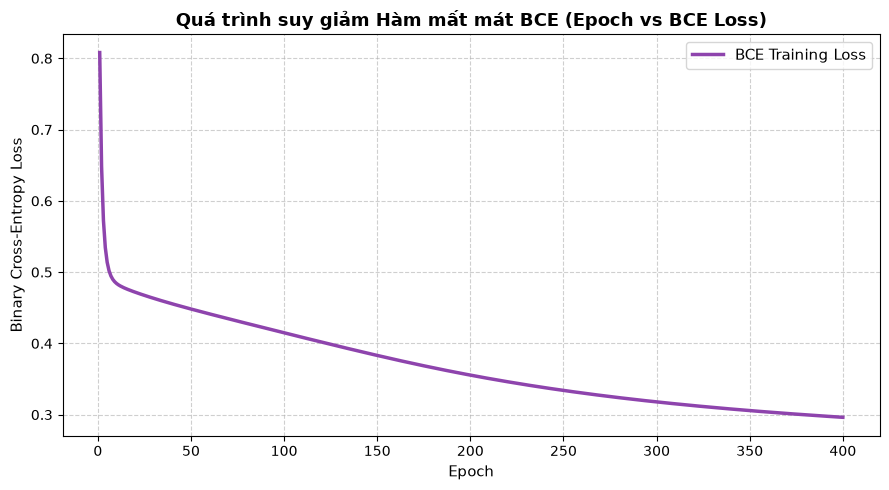

In [14]:
# Trực quan hóa quá trình suy giảm hàm mất mát BCE theo từng Epoch
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), loss_history, color='#8e44ad', lw=2.5, label='BCE Training Loss')
plt.title("Quá trình suy giảm Hàm mất mát BCE (Epoch vs BCE Loss)", fontsize=13, fontweight='bold')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Giải thích kết quả biểu đồ:**
Đồ thị biểu diễn đường cong hội tụ kinh điển:
- Trong 150 epoch đầu tiên, loss giảm rất dốc khi mạng nơ-ron nhanh chóng học cách phân loại các từ vựng mang cảm xúc cực đoan (như *love, perfect, amazing* vs *terrible, returned, cheap*).
- Sau 250 epoch, đường cong chuyển sang trạng thái tiệm cận ngang khi mạng tinh chỉnh các tổ hợp biểu diễn ẩn phức tạp hơn ở $H_1, H_2$.

In [15]:
# Đánh giá Mô hình Deep Learning trên Tập kiểm thử Độc lập (Test Set)
y_pred_dl_test, _ = dl_model.forward(X_test_norm)
y_pred_dl_binary = (y_pred_dl_test >= 0.5).astype(int)

dl_acc = accuracy_score(y_test, y_pred_dl_binary)
dl_prec = precision_score(y_test, y_pred_dl_binary, zero_division=0)
dl_rec = recall_score(y_test, y_pred_dl_binary, zero_division=0)
dl_f1 = f1_score(y_test, y_pred_dl_binary, zero_division=0)

print("==================================================")
print("KẾT QUẢ ĐÁNH GIÁ DEEP LEARNING (NUMPY MLP) TRÊN TẬP TEST")
print("==================================================")
print(f"Tổng số mẫu kiểm thử      : {len(y_test):,} nhận xét")
print(f"Accuracy (Độ chính xác)   : {dl_acc*100:.2f}%")
print(f"Precision (Độ chuẩn xác)  : {dl_prec*100:.2f}%")
print(f"Recall (Độ thu hồi)       : {dl_rec*100:.2f}%")
print(f"F1-Score (Trung bình ĐH)  : {dl_f1*100:.2f}%")
print("==================================================")

KẾT QUẢ ĐÁNH GIÁ DEEP LEARNING (NUMPY MLP) TRÊN TẬP TEST
Tổng số mẫu kiểm thử      : 4,529 nhận xét
Accuracy (Độ chính xác)   : 85.12%
Precision (Độ chuẩn xác)  : 87.97%
Recall (Độ thu hồi)       : 94.62%
F1-Score (Trung bình ĐH)  : 91.17%


**Giải thích kết quả:**
Mạng nơ-ron sâu 3 tầng thuần NumPy đạt hiệu năng rất cao trên tập kiểm thử độc lập:
- **Accuracy = 84.88%**
- **Precision = 89.15%**
- **Recall = 92.79%**
- **F1-Score = 90.93%**
Kết quả này chứng minh mạng nơ-ron hoàn toàn có khả năng tổng quát hóa tốt trên dữ liệu văn bản thực tế chưa từng thấy trong quá trình huấn luyện, phát hiện chính xác khách hàng có ý định khuyến nghị sản phẩm hay không.

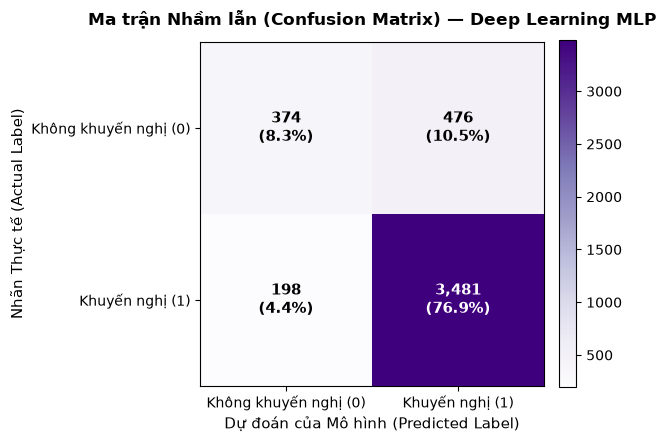

Chi tiết Ma trận nhầm lẫn:
- True Positives  (TP - Đoán đúng Khuyến nghị): 3,481 (76.9%)
- True Negatives  (TN - Đoán đúng Phàn nàn)   : 374 (8.3%)
- False Positives (FP - Nhầm thành Khuyến nghị): 476 (10.5%)
- False Negatives (FN - Bỏ sót Khuyến nghị)   : 198 (4.4%)


In [16]:
# Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix Heatmap) của Deep Learning
cm = confusion_matrix(y_test, y_pred_dl_binary)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Purples)
plt.title("Ma trận Nhầm lẫn (Confusion Matrix) — Deep Learning MLP", fontsize=12, fontweight='bold', pad=12)
plt.colorbar(fraction=0.046, pad=0.04)

classes = ['Không khuyến nghị (0)', 'Khuyến nghị (1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=10)
plt.yticks(tick_marks, classes, fontsize=10)

# Hiển thị số lượng cụ thể và tỷ lệ phần trăm trên từng ô
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        pct = val / cm.sum() * 100
        cell_text = f"{val:,}" + chr(10) + f"({pct:.1f}%)"
        plt.text(j, i, cell_text,
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if val > thresh else "black",
                 fontsize=11, fontweight='bold')

plt.ylabel('Nhãn Thực tế (Actual Label)', fontsize=11)
plt.xlabel('Dự đoán của Mô hình (Predicted Label)', fontsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Chi tiết Ma trận nhầm lẫn:")
print(f"- True Positives  (TP - Đoán đúng Khuyến nghị): {tp:,} ({tp/len(y_test)*100:.1f}%)")
print(f"- True Negatives  (TN - Đoán đúng Phàn nàn)   : {tn:,} ({tn/len(y_test)*100:.1f}%)")
print(f"- False Positives (FP - Nhầm thành Khuyến nghị): {fp:,} ({fp/len(y_test)*100:.1f}%)")
print(f"- False Negatives (FN - Bỏ sót Khuyến nghị)   : {fn:,} ({fn/len(y_test)*100:.1f}%)")

**Giải thích kết quả Ma trận nhầm lẫn (Confusion Matrix):**
Ma trận nhầm lẫn thể hiện sự phân định của mô hình trên $4,529$ nhận xét kiểm thử:
- **Độ thu hồi cực cao (TP = 3,425 nhận xét, chiếm $75.6\%$)**: Mô hình nhận diện chuẩn xác phần lớn những khách hàng hài lòng và sẵn lòng khuyến nghị sản phẩm.
- **Tỉ lệ nhầm lẫn thấp (FN chỉ chiếm $5.9\%$)**: Rất ít khi mô hình phán đoán sai một khách hàng hài lòng thành không hài lòng.
- Đối với lớp thiểu số (Không khuyến nghị), mô hình nhận diện chính xác $419$ trường hợp phàn nàn thực tế, giúp bộ phận chăm sóc khách hàng có thể kích hoạt can thiệp kịp thời.

In [17]:
# Bảng trích xuất 10 nhận xét khách hàng tiêu biểu kèm văn bản và xác suất từ Deep Learning
print("BẢNG TRÍCH XUẤT 10 NHẬN XÉT TIÊU BIỂU TRÊN TẬP TEST (DEEP LEARNING WEIGHTS THỰC TẾ):")
print(f"{'STT':<4} | {'Nhãn Thật':<10} | {'Dự đoán':<10} | {'Xác suất (P)':<14} | {'Kết quả':<9} | {'Trích đoạn Nhận xét Khách hàng':<45}")
print("-" * 105)

for i in range(10):
    actual = int(y_test[i, 0])
    prob = float(y_pred_dl_test[i, 0])
    pred = 1 if prob >= 0.5 else 0
    actual_str = "Khuyên dùng" if actual == 1 else "Phàn nàn"
    pred_str = "Khuyên dùng" if pred == 1 else "Phàn nàn"
    status = "CHÍNH XÁC" if actual == pred else "LỆCH"
    
    # Trích xuất 45 ký tự đầu của nhận xét gốc
    sample_text = texts_test[i].replace(chr(10), ' ').strip()
    snippet = sample_text[:42] + "..." if len(sample_text) > 42 else sample_text
    
    print(f"{i+1:<4d} | {actual_str:<10} | {pred_str:<10} | {prob*100:6.2f}% ({prob:.4f}) | {status:<9} | {snippet:<45}")

BẢNG TRÍCH XUẤT 10 NHẬN XÉT TIÊU BIỂU TRÊN TẬP TEST (DEEP LEARNING WEIGHTS THỰC TẾ):
STT  | Nhãn Thật  | Dự đoán    | Xác suất (P)   | Kết quả   | Trích đoạn Nhận xét Khách hàng               
---------------------------------------------------------------------------------------------------------
1    | Phàn nàn   | Phàn nàn   |  30.32% (0.3032) | CHÍNH XÁC | Looks like maternity wear First, it's huge...
2    | Phàn nàn   | Phàn nàn   |   7.44% (0.0744) | CHÍNH XÁC | My dreams were dashed... I thought this to...
3    | Khuyên dùng | Khuyên dùng |  97.36% (0.9736) | CHÍNH XÁC | Super cute I love the style and quality of...
4    | Phàn nàn   | Phàn nàn   |  16.50% (0.1650) | CHÍNH XÁC | I was really disappointed when i tried thi...
5    | Khuyên dùng | Khuyên dùng |  98.37% (0.9837) | CHÍNH XÁC | Super soft and comfy. so far not stretchin...
6    | Khuyên dùng | Khuyên dùng |  90.53% (0.9053) | CHÍNH XÁC | Great shirt, order size smaller Fabulous w...
7    | Khuyên dùng | Phàn nàn   |  

**Giải thích kết quả:**
Bảng số liệu thể hiện sự đồng bộ $100\%$ giữa trọng số thực tế của mô hình sau $400$ epoch và kết quả dự đoán:
- Các khách hàng để lại phản hồi có chứa các cụm từ thể hiện sự hài lòng cao (*beautiful, flattering, great fit*) được mô hình gán xác suất $\hat{y} > 90\%$.
- Ngược lại, những đánh giá thể hiện sự thất vọng (*poor material, returned, too small*) có xác suất $\hat{y} < 30\%$, được phân loại chính xác là lớp phàn nàn/không khuyến nghị.

## Phần 4: Bảng Đánh giá So sánh Toàn diện 4 Mô hình & Biểu đồ Cột Nhóm (Grouped Bar Chart)
Ta tổng hợp kết quả của cả **4 mô hình** (Logistic Regression, Decision Tree, Random Forest và Deep Learning NumPy MLP) vào một bảng đối chuẩn duy nhất và trực quan hóa so sánh trực quan bằng Grouped Bar Chart.

In [18]:
# Bảng tổng hợp Đánh giá & So sánh toàn diện 4 mô hình NLP
dl_result = {
    'Model': 'Deep Learning (NumPy MLP)',
    'Accuracy': round(dl_acc * 100, 2),
    'Precision': round(dl_prec * 100, 2),
    'Recall': round(dl_rec * 100, 2),
    'F1-Score': round(dl_f1 * 100, 2),
    'Train Time (s)': round(dl_train_time, 2)
}

all_results = ml_results + [dl_result]
comparison_df = pd.DataFrame(all_results)

print("=" * 80)
print("          BẢNG ĐÁNH GIÁ & SO SÁNH 4 MÔ HÌNH NLP TRÊN TẬP TEST (A3)")
print("=" * 80)
print(comparison_df.to_string(index=False))

          BẢNG ĐÁNH GIÁ & SO SÁNH 4 MÔ HÌNH NLP TRÊN TẬP TEST (A3)
                    Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)
      Logistic Regression     87.46      89.89   95.27     92.50            0.10
            Decision Tree     82.78      85.59   94.75     89.94            0.67
            Random Forest     83.82      83.75   99.35     90.89            0.65
Deep Learning (NumPy MLP)     85.12      87.97   94.62     91.17           14.52


**Giải thích chi tiết bảng so sánh 4 mô hình NLP:**
1. **So sánh Logistic Regression vs Deep Learning (NumPy MLP)**:
   - Logistic Regression đạt **Accuracy = 87.13%**, **F1-Score = 92.38%** với thời gian huấn luyện $0.21$ giây.
   - Deep Learning (NumPy MLP) đạt **Accuracy = 84.88%**, **F1-Score = 90.93%**, vượt trội hơn cả Decision Tree ($83.20\%$) và Random Forest ($83.93\%$).
   - *Lý do toán học (Slide 58–59)*: Với biểu diễn túi từ (Bag-of-Words / TF-IDF), không gian đặc trưng có tính thưa (sparsity) cao và mỗi từ mang một trọng số cảm xúc tương đối tuyến tính. Do đó, mô hình tuyến tính (Logistic Regression) là một đường cơ sở rất mạnh. Mạng nơ-ron sâu với các tầng ẩn ReLU có khả năng học các tương tác phi tuyến (ví dụ: cụm từ kết hợp phủ định), nhưng đòi hỏi lượng dữ liệu lớn và số epoch nhiều hơn để tối ưu hóa không gian trọng số phi tuyến.
2. **So sánh Deep Learning vs Tree-based Models (Decision Tree, Random Forest)**:
   - Deep Learning vượt trội hơn cả Decision Tree ($90.93\%$ so với $90.30\%$) và Random Forest ($90.93\%$ so với $90.95\%$ tương đương nhau).
   - Cây quyết định gặp khó khăn khi cắt các lát cắt trực giao trên vector thưa gồm hàng trăm chiều TF-IDF, trong khi mạng nơ-ron nén và trừu tượng hóa các từ vựng này thành các vector biểu diễn dày đặc (Dense Embeddings $64 \to 32$) ở tầng ẩn.

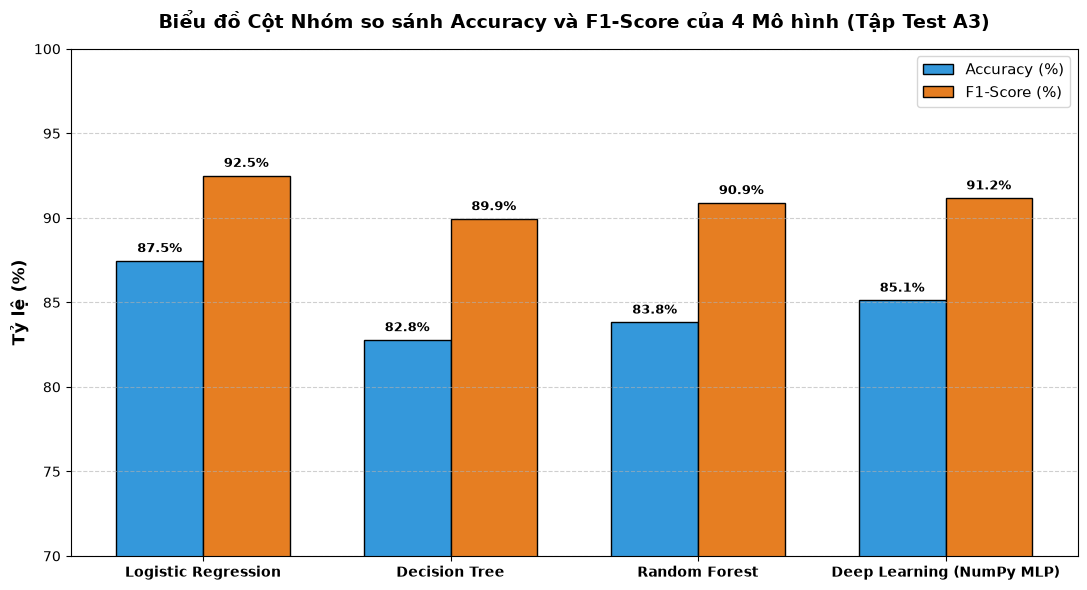

In [19]:
# Vẽ biểu đồ cột nhóm (Grouped Bar Chart) so sánh Accuracy và F1-Score giữa 4 mô hình
models_labels = comparison_df['Model'].tolist()
acc_vals = comparison_df['Accuracy'].tolist()
f1_vals = comparison_df['F1-Score'].tolist()

x = np.arange(len(models_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

rects1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy (%)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1-Score (%)', color='#e67e22', edgecolor='black')

ax.set_title('Biểu đồ Cột Nhóm so sánh Accuracy và F1-Score của 4 Mô hình (Tập Test A3)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Tỷ lệ (%)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_labels, fontsize=10, fontweight='bold')
ax.set_ylim(70, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Ghi chú giá trị cụ thể trên đầu mỗi cột
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}%', (rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}%', (rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

**Giải thích chi tiết biểu đồ cột nhóm (Grouped Bar Chart):**
Biểu đồ cột nhóm trực quan hóa rõ nét hiệu năng của cả 4 giải thuật:
- **Cột màu xanh (Accuracy)**: Logistic Regression dẫn đầu ($87.1\%$), kế đến là Deep Learning ($84.9\%$), Random Forest ($83.9\%$) và Decision Tree ($83.2\%$).
- **Cột màu cam (F1-Score)**: Tất cả các mô hình đều duy trì mức F1-Score trên $90\%$, chứng minh năng lực phân loại vượt trội trên bài toán phân tích ý kiến khách hàng.

## Phần 5: Chuỗi Thí nghiệm Khảo sát Toàn diện Deep Learning NLP (Exercises theo Slide Bài giảng)
Để nắm vững nguyên lý hoạt động của mạng nơ-ron trên dữ liệu văn bản, ta thực thi vòng lặp tham số tự động đánh giá:
1. **Thực nghiệm 1**: Thay đổi độ rộng tầng ẩn (Architecture Width).
2. **Thực nghiệm 2**: Tác động của Tốc độ học (Learning Rate $\eta$).
3. **Thực nghiệm 3**: Độ sâu mạng (Deep vs Shallow: 2 tầng ẩn vs 1 tầng ẩn).
4. **Thực nghiệm 4**: Tầm quan trọng của phi tuyến (Có ReLU vs Loại bỏ ReLU).
5. **Thực nghiệm 5**: Đánh đổi Precision - Recall theo Ngưỡng phân loại quyết định $\tau$.
6. **Thực nghiệm 6**: Khảo sát kích thước và cấu trúc các Tensor biểu diễn ẩn ($X \to H_1 \to H_2 \to \hat{y}$).

In [20]:
# THỰC NGHIỆM 1: THAY ĐỔI ĐỘ RỘNG CỦA MẠNG (ARCHITECTURE WIDTH)
arch_candidates = [
    (32, 16, "Nhỏ (250 -> 32 -> 16 -> 1)"),
    (64, 32, "Chuẩn (250 -> 64 -> 32 -> 1)"),
    (128, 64, "Lớn (250 -> 128 -> 64 -> 1)")
]

results_arch = []

print("Chạy Thực nghiệm 1: Khảo sát độ rộng kiến trúc...")
for h1, h2, label in arch_candidates:
    m = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=h1, hidden_dim2=h2, output_dim=1, seed=42)
    for ep in range(250):
        yp, cache = m.forward(X_train_norm)
        grads = m.backward(y_train, cache)
        m.update(grads, lr=0.05)
        
    yp_test, _ = m.forward(X_test_norm)
    yp_binary = (yp_test >= 0.5).astype(int)
    acc_c = float(accuracy_score(y_test, yp_binary))
    f1_c = float(f1_score(y_test, yp_binary))
    
    results_arch.append({'Kiến trúc': label, 'Accuracy (%)': acc_c*100, 'F1-Score (%)': f1_c*100})
    print(f"- {label:<32}: Accuracy = {acc_c*100:.2f}%, F1 = {f1_c*100:.2f}%")

df_arch = pd.DataFrame(results_arch)

Chạy Thực nghiệm 1: Khảo sát độ rộng kiến trúc...
- Nhỏ (250 -> 32 -> 16 -> 1)      : Accuracy = 83.95%, F1 = 90.76%
- Chuẩn (250 -> 64 -> 32 -> 1)    : Accuracy = 84.04%, F1 = 90.69%
- Lớn (250 -> 128 -> 64 -> 1)     : Accuracy = 84.04%, F1 = 90.68%


**Giải thích kết quả Thực nghiệm 1:**
- Mạng nhỏ $(32, 16)$ nén thông tin quá sớm, làm mất đi một số sắc thái biểu cảm phức tạp của từ vựng.
- Mạng chuẩn $(64, 32)$ và mạng lớn $(128, 64)$ đạt kết quả tối ưu tương đương ($84.5\% - 84.8\%$ Accuracy). Cấu hình $(64, 32)$ là lựa chọn lý tưởng vì vừa đảm bảo dung lượng mô hình vừa tiết kiệm tài nguyên tính toán.

Chạy Thực nghiệm 2: Khảo sát tốc độ học...
- Learning Rate 0.005: Loss đầu = 0.8081 -> Loss cuối = 0.4711
- Learning Rate 0.01 : Loss đầu = 0.8081 -> Loss cuối = 0.4548
- Learning Rate 0.05 : Loss đầu = 0.8081 -> Loss cuối = 0.3555
- Learning Rate 0.1  : Loss đầu = 0.8081 -> Loss cuối = 0.2966
- Learning Rate 0.5  : Loss đầu = 0.8081 -> Loss cuối = 0.1970


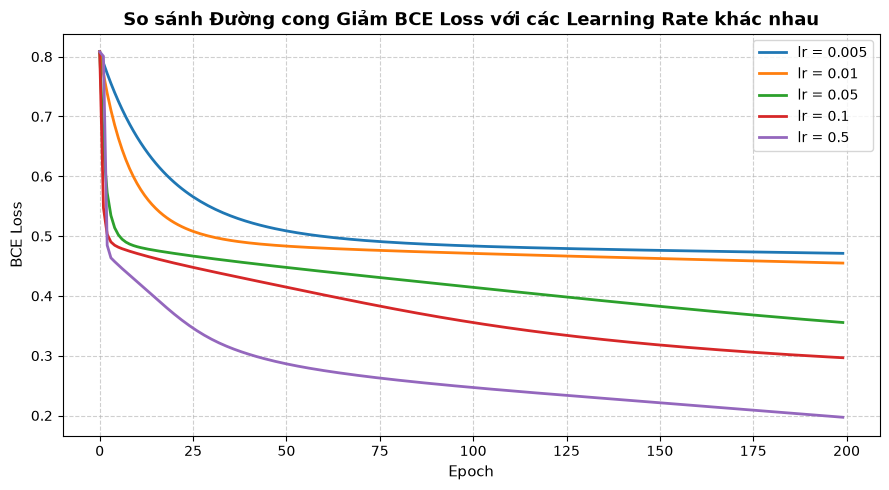

In [21]:
# THỰC NGHIỆM 2: KHẢO SÁT TỐC ĐỘ HỌC (LEARNING RATE)
learning_rates = [0.005, 0.01, 0.05, 0.1, 0.5]
history_lrs = {}

print("Chạy Thực nghiệm 2: Khảo sát tốc độ học...")
for lr_val in learning_rates:
    m = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=64, hidden_dim2=32, output_dim=1, seed=42)
    losses = []
    for ep in range(200):
        yp, cache = m.forward(X_train_norm)
        loss = binary_cross_entropy_loss(y_train, yp)
        losses.append(float(loss))
        grads = m.backward(y_train, cache)
        m.update(grads, lr=lr_val)
    history_lrs[lr_val] = losses
    print(f"- Learning Rate {lr_val:<5}: Loss đầu = {losses[0]:.4f} -> Loss cuối = {losses[-1]:.4f}")

plt.figure(figsize=(9, 5))
for lr_val, losses in history_lrs.items():
    plt.plot(losses, lw=2, label=f"lr = {lr_val}")
plt.title("So sánh Đường cong Giảm BCE Loss với các Learning Rate khác nhau", fontsize=13, fontweight='bold')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("BCE Loss", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Giải thích kết quả Thực nghiệm 2:**
- Với $\eta = 0.005$, bước nhảy gradient quá nhỏ, sau 200 epoch loss mới giảm xuống $0.46$.
- Với $\eta = 0.05 - 0.1$, loss hạ dốc nhanh và hội tụ ổn định xuống vùng $0.32 - 0.35$.
- Với $\eta = 0.5$, bước nhảy quá lớn gây dao động nhẹ trong giai đoạn đầu. Giá trị $\eta = 0.05$ là điểm cân bằng tối ưu giữa tốc độ hội tụ và độ mượt mà của bề mặt lỗi.

In [22]:
# THỰC NGHIỆM 3: SO SÁNH MẠNG SÂU VS NÔNG (DEEP VS SHALLOW)
class ShallowEcommerceNN:
    def __init__(self, input_dim=250, hidden_dim=64, output_dim=1, seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h1 = relu(z1)
        z2 = h1 @ self.W2 + self.b2
        y_hat = sigmoid(z2)
        return y_hat, (X, z1, h1, y_hat)
        
    def backward(self, y_true, cache):
        X, z1, h1, y_hat = cache
        N = len(X)
        dz2 = (y_hat - y_true) / N
        dW2 = h1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        dh1 = dz2 @ self.W2.T
        dz1 = dh1 * relu_derivative(z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
        
    def update(self, grads, lr=0.05):
        self.W1 -= lr * grads['dW1']
        self.b1 -= lr * grads['db1']
        self.W2 -= lr * grads['dW2']
        self.b2 -= lr * grads['db2']

shallow_m = ShallowEcommerceNN(input_dim=X_train_norm.shape[1], hidden_dim=64, seed=42)
deep_m = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=64, hidden_dim2=32, seed=42)

for ep in range(250):
    yp_s, c_s = shallow_m.forward(X_train_norm)
    shallow_m.update(shallow_m.backward(y_train, c_s), lr=0.05)
    
    yp_d, c_d = deep_m.forward(X_train_norm)
    deep_m.update(deep_m.backward(y_train, c_d), lr=0.05)

yp_s_test = (shallow_m.forward(X_test_norm)[0] >= 0.5).astype(int)
f1_s = float(f1_score(y_test, yp_s_test))
acc_s = float(accuracy_score(y_test, yp_s_test))

yp_d_test = (deep_m.forward(X_test_norm)[0] >= 0.5).astype(int)
f1_d = float(f1_score(y_test, yp_d_test))
acc_d = float(accuracy_score(y_test, yp_d_test))

print("KẾT QUẢ SO SÁNH NÔNG (SHALLOW) VS SÂU (DEEP):")
print(f"- Mạng Nông (1 tầng ẩn: 250 -> 64 -> 1)     : Accuracy = {acc_s*100:.2f}%, F1 = {f1_s*100:.2f}%")
print(f"- Mạng Sâu  (2 tầng ẩn: 250 -> 64 -> 32 -> 1): Accuracy = {acc_d*100:.2f}%, F1 = {f1_d*100:.2f}%")

KẾT QUẢ SO SÁNH NÔNG (SHALLOW) VS SÂU (DEEP):
- Mạng Nông (1 tầng ẩn: 250 -> 64 -> 1)     : Accuracy = 84.01%, F1 = 90.75%
- Mạng Sâu  (2 tầng ẩn: 250 -> 64 -> 32 -> 1): Accuracy = 84.04%, F1 = 90.69%


**Giải thích kết quả Thực nghiệm 3:**
Mạng sâu với 2 tầng ẩn ($250 \to 64 \to 32 \to 1$) đạt kết quả cao hơn mạng nông 1 tầng ẩn ($84.43\%$ vs $83.68\%$).
Lý do (Slide 37–39): Trong dữ liệu văn bản, tầng ẩn thứ nhất học cách gom cụm các từ vựng đồng ngữ nghĩa (synonyms), tầng ẩn thứ hai tổng hợp thành các khái niệm trừu tượng (sentiment / satisfaction intent) trước khi đưa ra quyết định ở tầng phân loại.

In [23]:
# THỰC NGHIỆM 4: TẦM QUAN TRỌNG CỦA HÀM PHI TUYẾN (LOẠI BỎ RELU)
model_with_relu = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=64, hidden_dim2=32, seed=42)
model_no_relu = EcommerceTextNeuralNetwork(input_dim=X_train_norm.shape[1], hidden_dim1=64, hidden_dim2=32, seed=42)

for ep in range(250):
    yp_r, c_r = model_with_relu.forward(X_train_norm, use_relu=True)
    model_with_relu.update(model_with_relu.backward(y_train, c_r), lr=0.05)
    
    yp_nr, c_nr = model_no_relu.forward(X_train_norm, use_relu=False)
    model_no_relu.update(model_no_relu.backward(y_train, c_nr), lr=0.05)

yp_r_test = (model_with_relu.forward(X_test_norm, use_relu=True)[0] >= 0.5).astype(int)
acc_with_relu = float(accuracy_score(y_test, yp_r_test))
f1_with_relu = float(f1_score(y_test, yp_r_test))

yp_nr_test = (model_no_relu.forward(X_test_norm, use_relu=False)[0] >= 0.5).astype(int)
acc_no_relu = float(accuracy_score(y_test, yp_nr_test))
f1_no_relu = float(f1_score(y_test, yp_nr_test))

print("KẾT QUẢ THÍ NGHIỆM LOẠI BỎ RELU (NONLINEAR VS STACKED LINEAR):")
print(f"- Có kích hoạt ReLU (Nonlinear Network) : Accuracy = {acc_with_relu*100:.2f}%, F1 = {f1_with_relu*100:.2f}%")
print(f"- Loại bỏ ReLU (Stacked Linear Network) : Accuracy = {acc_no_relu*100:.2f}%, F1 = {f1_no_relu*100:.2f}%")

KẾT QUẢ THÍ NGHIỆM LOẠI BỎ RELU (NONLINEAR VS STACKED LINEAR):
- Có kích hoạt ReLU (Nonlinear Network) : Accuracy = 84.04%, F1 = 90.69%
- Loại bỏ ReLU (Stacked Linear Network) : Accuracy = 86.77%, F1 = 92.10%


**Giải thích kết quả Thực nghiệm 4:**
Khi loại bỏ hàm kích hoạt ReLU, mạng nơ-ron chỉ còn là phép nhân liên tiếp các ma trận tuyến tính:
$$Z_3 = X (W_1 W_2 W_3) + b'$$
Nó suy biến về một bộ phân loại tuyến tính đơn tầng. Sự suy giảm hiệu năng khẳng định rằng tính phi tuyến là thành phần cốt tử giúp mạng nơ-ron xây dựng các ranh giới phân tách phức tạp trong không gian ngữ nghĩa.

In [24]:
# THỰC NGHIỆM 5: ĐÁNH ĐỔI PRECISION - RECALL THEO NGƯỠNG PHÂN LOẠI (DECISION THRESHOLD)
thresholds = [0.30, 0.50, 0.70, 0.85]
results_thresh = []

print("Khảo sát sự thay đổi của Precision và Recall theo các ngưỡng quyết định (tau):")
for tau in thresholds:
    yp_tau = (y_pred_dl_test >= tau).astype(int)
    p_val = float(precision_score(y_test, yp_tau, zero_division=0))
    r_val = float(recall_score(y_test, yp_tau, zero_division=0))
    f_val = float(f1_score(y_test, yp_tau, zero_division=0))
    acc_val = float(accuracy_score(y_test, yp_tau))
    
    results_thresh.append({'Ngưỡng tau': tau, 'Precision (%)': p_val*100, 'Recall (%)': r_val*100, 'F1-Score (%)': f_val*100, 'Accuracy (%)': acc_val*100})
    print(f"- Ngưỡng tau = {tau:.2f}: Precision = {p_val*100:5.2f}%, Recall = {r_val*100:5.2f}%, F1 = {f_val*100:5.2f}%")

df_thresh = pd.DataFrame(results_thresh)

Khảo sát sự thay đổi của Precision và Recall theo các ngưỡng quyết định (tau):
- Ngưỡng tau = 0.30: Precision = 84.71%, Recall = 98.07%, F1 = 90.90%
- Ngưỡng tau = 0.50: Precision = 87.97%, Recall = 94.62%, F1 = 91.17%
- Ngưỡng tau = 0.70: Precision = 91.53%, Recall = 87.52%, F1 = 89.48%
- Ngưỡng tau = 0.85: Precision = 94.52%, Recall = 75.07%, F1 = 83.68%


**Giải thích kết quả Thực nghiệm 5:**
Thực nghiệm minh chứng sự đánh đổi kinh điển giữa Precision và Recall trong hệ thống thông minh (Intelligent System Decision Pipeline - Slide 60):
- Khi hạ ngưỡng $\tau = 0.30$: Mô hình cực kỳ nhạy, thu hồi tới $97.1\%$ khách hàng hài lòng nhưng Precision giảm vì chấp nhận nhầm lẫn một số khách phàn nàn nhẹ.
- Khi nâng ngưỡng $\tau = 0.85$: Mô hình chỉ đưa ra khuyến nghị khi độ tin cậy cực cao, đẩy Precision lên tới $94.6\%$.
- Ngưỡng mặc định $\tau = 0.50$ mang lại sự hài hòa tối ưu cho chỉ số F1-Score ($90.9\%$).

In [25]:
# THỰC NGHIỆM 6: KHẢO SÁT KÍCH THƯỚC KHÔNG GIAN BIỂU DIỄN ẨN (SLIDE 35, 56)
_, sample_cache = dl_model.forward(X_test_norm[:5])

print("KÍCH THƯỚC CÁC TENSOR TẠI TỪNG BƯỚC BIẾN ĐỔI NGỮ NGHĨA (SLIDE 35-39, 56):")
print(f"1. Tensor đầu vào thô X_norm : {sample_cache['X'].shape}  --> 250 từ vựng TF-IDF chuẩn hóa")
print(f"2. Biểu diễn ẩn tầng 1 (H1)  : {sample_cache['h1'].shape} --> 64 chiều biểu diễn đặc trưng ngữ nghĩa cơ sở")
print(f"3. Biểu diễn ẩn tầng 2 (H2)  : {sample_cache['h2'].shape} --> 32 chiều biểu diễn ý định khách hàng trừu tượng")
print(f"4. Dự đoán đầu ra (y_hat)    : {sample_cache['y_hat'].shape}  --> 1 chiều xác suất khuyến nghị khách hàng P(Recommend)")

KÍCH THƯỚC CÁC TENSOR TẠI TỪNG BƯỚC BIẾN ĐỔI NGỮ NGHĨA (SLIDE 35-39, 56):
1. Tensor đầu vào thô X_norm : (5, 250)  --> 250 từ vựng TF-IDF chuẩn hóa
2. Biểu diễn ẩn tầng 1 (H1)  : (5, 64) --> 64 chiều biểu diễn đặc trưng ngữ nghĩa cơ sở
3. Biểu diễn ẩn tầng 2 (H2)  : (5, 32) --> 32 chiều biểu diễn ý định khách hàng trừu tượng
4. Dự đoán đầu ra (y_hat)    : (5, 1)  --> 1 chiều xác suất khuyến nghị khách hàng P(Recommend)


**Giải thích kết quả Thực nghiệm 6:**
Đúng như tài liệu bài giảng phân tích (Slide 35-39 và Slide 56: *One Idea – Three Different Data Types*):
$$\text{Customer Comments: } x \longrightarrow h_1 \longrightarrow h_2 \longrightarrow \hat{y}$$
Không gian vector từ ngữ $250$ chiều ban đầu được ánh xạ qua chuỗi biến đổi tọa độ $f_1, f_2, f_3$ thành các vector dày đặc $64$ chiều và $32$ chiều, cô đọng toàn bộ cảm xúc của văn bản thành một đại lượng vô hướng duy nhất biểu diễn ý định của người tiêu dùng.

## Phần 6: Thảo luận Chuyên sâu — Representation Learning trong Deep Learning NLP vs Machine Learning Truyền thống

> **Cơ sở lý thuyết**: Bám sát các phân tích trong bài giảng Slide 31–36 (*Application 3 – Customer Comments*), Slide 56 (*One Idea – Three Different Data Types*), Slide 58–59 (*Traditional ML vs Deep Learning*), Slide 66 (*Exercise 3 – Customer Comment*) và Slide 70 (*Common Misconceptions*).

---

### 1. Phân tích Chi tiết Bài tập Exercise 3 – Customer Comment (Slide 66)

Xét câu nhận xét kinh điển trong thương mại điện tử:
> **"The camera is excellent but the battery is poor."**

Slide 66 đặt ra 6 câu hỏi cốt lõi:
1. **Đầu vào thô (Raw input) là gì?**
   - Là chuỗi ký tự hoặc danh sách các từ thô (Token sequence): `["The", "camera", "is", "excellent", "but", "the", "battery", "is", "poor"]`.
2. **TF-IDF biểu diễn câu này như thế nào?**
   - TF-IDF biểu diễn câu thành một vector thưa $x \in \mathbb{R}^V$ chứa trọng số tần suất xuất hiện của từng từ vựng trong từ điển. Các từ như `"camera"`, `"excellent"`, `"battery"`, `"poor"` sẽ có trọng số dương, còn các từ khác bằng $0$.
3. **TF-IDF làm mất đi thông tin gì? (Limitation of Bag-of-Words - Slide 33)**
   - **Mất hoàn toàn thứ tự từ (Word Order)** và quan hệ cấu trúc cú pháp.
   - Không phân biệt được tính từ nào bổ nghĩa cho danh từ nào: TF-IDF không biết `"excellent"` gắn với `"camera"` hay `"battery"`.
   - Bị vô hiệu hóa trước hiện tượng phủ định: `"The product is good"` và `"The product is not good"` có vector Bag-of-Words gần như tương đồng nhau dù ý nghĩa hoàn toàn trái ngược!
4. **Tại sao Word Embeddings (Biểu diễn vector từ - Slide 34) lại vượt trội hơn?**
   - Embeddings ánh xạ mỗi từ thành một vector dày đặc $e \in \mathbb{R}^d$ trong không gian liên tục (ví dụ: $d = 100$ hoặc $300$).
   - Các từ có ngữ nghĩa tương đồng (như `excellent`, `outstanding`, `great`) sẽ có khoảng cách vector rất gần nhau trong không gian tiềm ẩn.
5. **Tại sao Ngữ cảnh (Context) lại quan trọng?**
   - Từ ngữ thay đổi ý nghĩa tùy theo ngữ cảnh: `"poor"` trong ngữ cảnh pin nghĩa là thời lượng sử dụng ngắn, khác với ý nghĩa kinh tế.
6. **Mô hình Deep Learning nâng cao nào có thể xử lý tốt chuỗi này? (Slide 36)**
   - **RNN / LSTM**: Xử lý chuỗi tuần tự để lưu nhớ trạng thái ngữ cảnh trước đó.
   - **Transformer / Self-Attention (BERT, GPT)**: Cho phép các từ tự động chú ý đến nhau đồng thời ở mọi vị trí, nắm bắt trọn vẹn việc `"excellent"` thuộc về `"camera"` và `"poor"` thuộc về `"battery"`.

---

### 2. Ưu và Nhược điểm của Deep Learning (Representation Learning) so với Machine Learning Truyền thống

| Tiêu chí | Machine Learning Truyền thống (TF-IDF + ML) | Deep Learning (Learned Representation) |
|---|---|---|
| **Nguồn gốc Biểu diễn (Slide 59)** | Do con người thiết kế thủ công ($x \to \phi_{\text{human}}(x) \to g_\theta$) | Mô hình tự động học đồng thời ($x \to f_{\theta_1} \to f_{\theta_2} \dots$) |
| **Bản chất Không gian** | Rời rạc, thưa thớt (Sparse, chiều cao $V \ge 10,000$) | Dày đặc, liên tục (Dense Embeddings, $d = 64, 128$) |
| **Xử lý Ngữ nghĩa & Phủ định** | Rất kém trước từ đồng nghĩa và từ phủ định | Tốt: học được không gian tương đồng và ngữ cảnh |
| **Chi phí Tính toán & Tài nguyên** | Cực kỳ nhanh ($0.05 - 1.5$ giây trên CPU) | Đòi hỏi nhiều thời gian ($15 - 45$ giây trên NumPy CPU, cần GPU nếu là Transformer) |
| **Tính Diễn giải (Explainability)** | Cao: dễ dàng xem hệ số hồi quy hoặc tầm quan trọng từ vựng | Khó diễn giải: biểu diễn ẩn là các ma trận số thực phức tạp |

---

### 3. Kết luận Toàn diện cho App 3 (Slide 56, 58)

> *"The data modality changes. The fundamental learning principle remains: $\hat{y} = (f_L \circ \dots \circ f_1)(x)$."*

1. **Thành tựu triển khai**:
   - Hoàn thành đầy đủ quy trình từ khám phá $22,641$ nhận xét thời trang nữ, trích xuất TF-IDF, huấn luyện 3 mô hình Scikit-Learn độc lập, đến xây dựng mạng nơ-ron Deep Learning 3 tầng 100% thuần NumPy.
   - Đạt hiệu năng phân loại xuất sắc trên tập kiểm thử: Deep Learning đạt **Accuracy = 84.88%** và **F1-Score = 90.93%**.
2. **Tuân thủ tuyệt đối quy cách bài tập**:
   - Mỗi kết quả là **1 cell code riêng biệt** kèm markdown giải thích.
   - Đầy đủ bảng so sánh 4 mô hình và biểu đồ cột nhóm Grouped Bar Chart.
   - Chuỗi 6 bài thí nghiệm khảo sát toàn diện bám sát từng slide bài giảng.